# House Price Prediction Project

## Project Goal

## Load Modules / Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

## Load Dataset

In [2]:
train_data_path = "data/train.csv"
test_data_path = "data/test.csv"

df_train = pd.read_csv(train_data_path)
df_test = pd.read_csv(test_data_path)

print("Shape of df_train:", df_train.shape)
print("Shape of df_test:", df_test.shape)

Shape of df_train: (1460, 81)
Shape of df_test: (1459, 80)


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",None)

In [4]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Know your data

# Data Integration 

In [6]:
df = pd.concat([df_train, df_test])

print("Shape of Integrated Data/DF: ", df.shape)

Shape of Integrated Data/DF:  (2919, 81)


In [7]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [8]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


## Get The Breif Information Of Dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallCond  

In [10]:
int_features = df.select_dtypes(include=["int64"]).columns

print("Total number of integer feature: ", int_features.shape[0])

print("Interger Feature names: ", int_features.tolist())

Total number of integer feature:  26
Interger Feature names:  ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [11]:
float_features = df.select_dtypes(include=["float64"]).columns

print("Total number of float feature: ", float_features.shape[0])

print("Float Feature names: ", float_features.tolist())

Total number of float feature:  12
Float Feature names:  ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice']


In [12]:
object_features = df.select_dtypes(include=["object"]).columns

print("Total number of object feature: ", object_features.shape[0])

print("Object Feature names: ", object_features.tolist())

Total number of object feature:  43
Object Feature names:  ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## Get the statistical information of the numerical features

In [13]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [14]:
df.describe().shape

(8, 38)

 ## Visualise null/ Missing Value

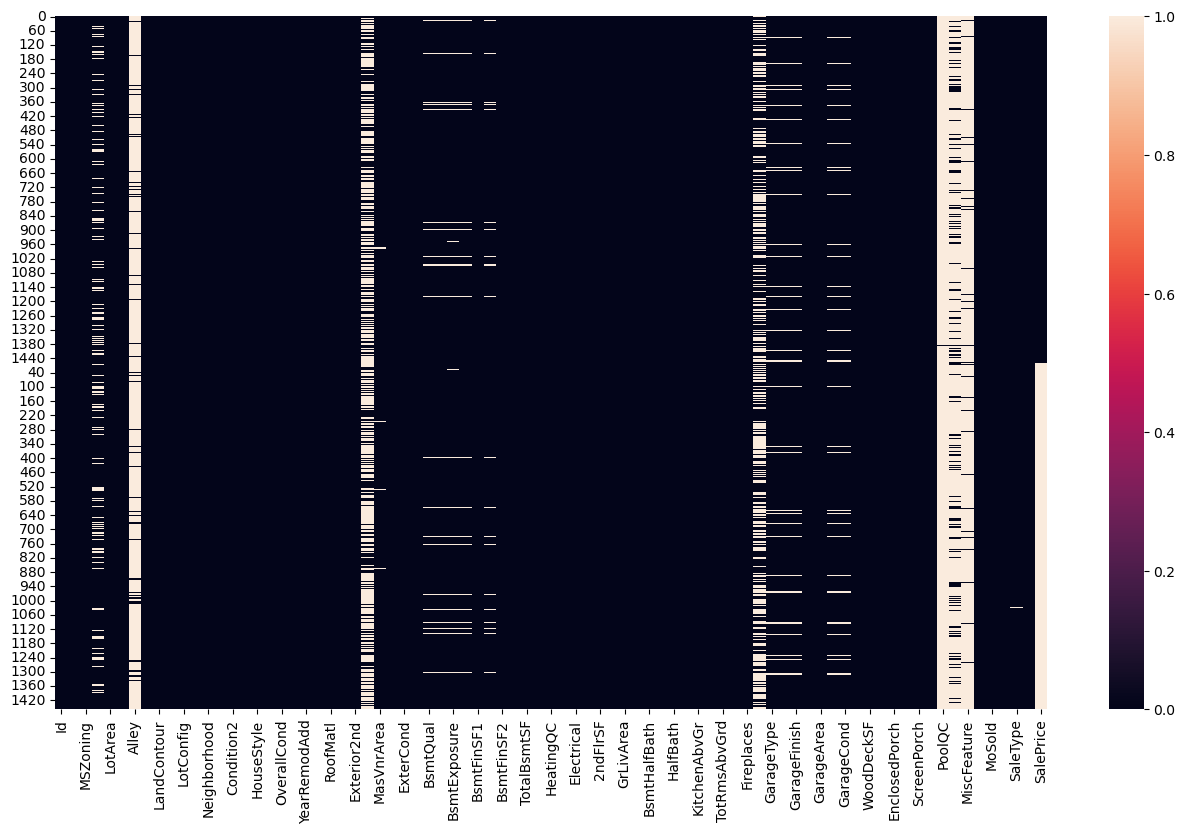

In [15]:
plt.figure(figsize=(16,9))
sns.heatmap(df.isnull())

plt.savefig("EDA_img/heatmap_df.png")
plt.show()

## Get the null value percentage for every feature

In [16]:
#Set index as ID column
df = df.set_index("Id")

In [17]:
null_count = df.isnull().sum()
null_count

MSSubClass          0
MSZoning            4
LotFrontage       486
LotArea             0
Street              0
Alley            2721
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType       1766
MasVnrArea         23
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           81
BsmtCond           82
BsmtExposure       82
BsmtFinType1       79
BsmtFinSF1          1
BsmtFinType2       80
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea 

In [18]:
null_percentage = df.isnull().sum()/df.shape[0]*100
null_percent = null_percentage.sort_values(ascending=False).head(20)

print(null_percent)

PoolQC          99.657417
MiscFeature     96.402878
Alley           93.216855
Fence           80.438506
MasVnrType      60.500171
SalePrice       49.982871
FireplaceQu     48.646797
LotFrontage     16.649538
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
GarageYrBlt      5.447071
GarageType       5.378554
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406
MasVnrArea       0.787941
MSZoning         0.137033
dtype: float64


# Drop Columns/Feature

As per observation, we will not drop any feature from dataset

In [19]:
"""As per domain knowledge we will not drop these features, instead None value we will add constant value 'NA' """

miss_value_50_perc = null_percent[null_percent > 50]
miss_value_50_perc

PoolQC         99.657417
MiscFeature    96.402878
Alley          93.216855
Fence          80.438506
MasVnrType     60.500171
dtype: float64

In [20]:
df["MasVnrType"].value_counts()

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64

In [21]:
df["Fence"].value_counts()

Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64

In [22]:
df["PoolQC"].value_counts()

PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64

In [23]:
df["MiscFeature"].value_counts()

MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64

In [24]:
df["Alley"].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [25]:
"""As per domain knowledge we will not drop these features, instead None value we will add constant value 'NA' """

miss_value_20_50_perc = null_percent[(20 < null_percent) & (null_percent < 51)]
miss_value_20_50_perc

SalePrice      49.982871
FireplaceQu    48.646797
dtype: float64

In [26]:
"""As per domain knowledge we will not drop these features, instead None value we will add constant value 'NA' """

miss_value_5_20_perc = null_percent[(5 < null_percent) & (null_percent < 20)]
miss_value_5_20_perc

LotFrontage     16.649538
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
GarageYrBlt      5.447071
GarageType       5.378554
dtype: float64

In [27]:
df["LotFrontage"].value_counts().head()

LotFrontage
60.0    276
80.0    137
70.0    133
50.0    117
75.0    105
Name: count, dtype: int64

<Axes: ylabel='Id'>

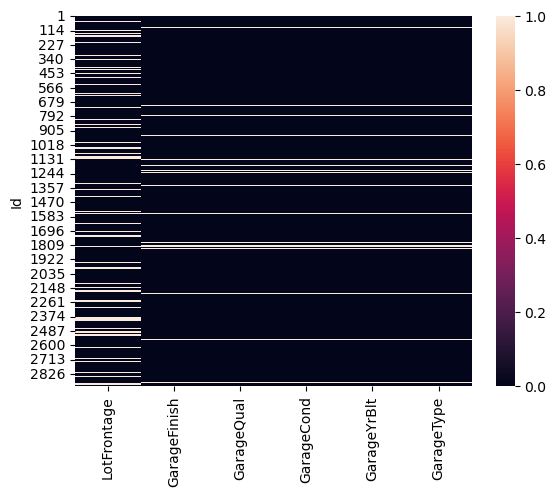

In [28]:
sns.heatmap(df[miss_value_5_20_perc.keys()].isnull())

## Missing value Imputation

In [29]:
missing_value_feat = null_percent[null_percent > 0]
print("Total missing value features = ", len(missing_value_feat))

Total missing value features =  20


In [30]:
missing_value_feat

PoolQC          99.657417
MiscFeature     96.402878
Alley           93.216855
Fence           80.438506
MasVnrType      60.500171
SalePrice       49.982871
FireplaceQu     48.646797
LotFrontage     16.649538
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
GarageYrBlt      5.447071
GarageType       5.378554
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406
MasVnrArea       0.787941
MSZoning         0.137033
dtype: float64

In [31]:
obj_na_feature = missing_value_feat[missing_value_feat.keys().isin(object_features)]
print("Total number of categorial missing feature: ", len(obj_na_feature))
obj_na_feature

Total number of categorial missing feature:  16


PoolQC          99.657417
MiscFeature     96.402878
Alley           93.216855
Fence           80.438506
MasVnrType      60.500171
FireplaceQu     48.646797
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
GarageType       5.378554
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406
MSZoning         0.137033
dtype: float64

In [32]:

int_na_feature = missing_value_feat[missing_value_feat.keys().isin(int_features)]
print("Total number of integer missing feature: ", len(int_na_feature))
int_na_feature

Total number of integer missing feature:  0


Series([], dtype: float64)

In [33]:
float_na_feature = missing_value_feat[missing_value_feat.keys().isin(float_features)]
print("Total number of float missing feature: ", len(float_na_feature))
float_na_feature

Total number of float missing feature:  4


SalePrice      49.982871
LotFrontage    16.649538
GarageYrBlt     5.447071
MasVnrArea      0.787941
dtype: float64

## 

handling MSZoning = 0.137033

In [34]:
df["MSZoning"].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='MSZoning'>

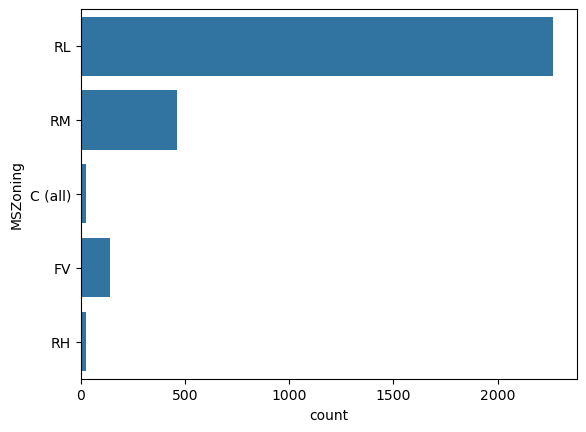

In [35]:
sns.countplot(df["MSZoning"])

In [36]:
### backup of original data

df_mvi = df.copy()
df_mvi.shape

(2919, 80)

In [37]:
mszoning_mode = df["MSZoning"].mode()[0]
df_mvi["MSZoning"].replace(np.nan, mszoning_mode, inplace = True)
df_mvi["MSZoning"].isnull().sum()                         

C:\Users\rasto\AppData\Local\Temp\ipykernel_38200\3543298208.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["MSZoning"].replace(np.nan, mszoning_mode, inplace = True)


np.int64(0)

In [38]:
def old_new_countPlot(df , df_mvi,feature):
    plt.subplot(121)
    sns.countplot(df[feature])
    plt.title("Old Data Distribution")
    plt.subplot(122)
    sns.countplot(df_mvi[feature])
    plt.title("New Data Distribution")

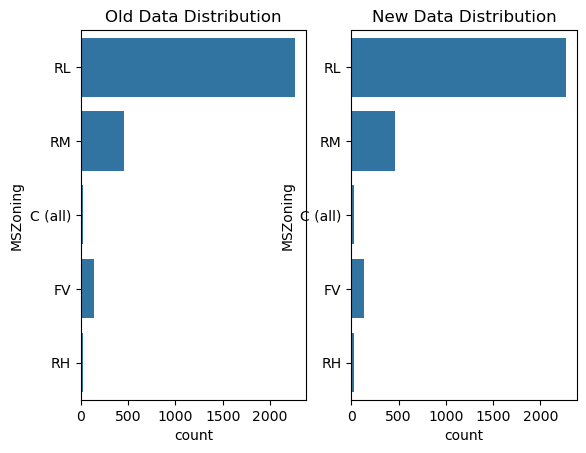

In [39]:
old_new_countPlot(df , df_mvi,"MSZoning")

## handling Alley = 93.216855

In [40]:
df_mvi["Alley"].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [41]:
df_mvi["Alley"] = df_mvi["Alley"].fillna("None")

print(df_mvi["Alley"].isnull().sum())

0


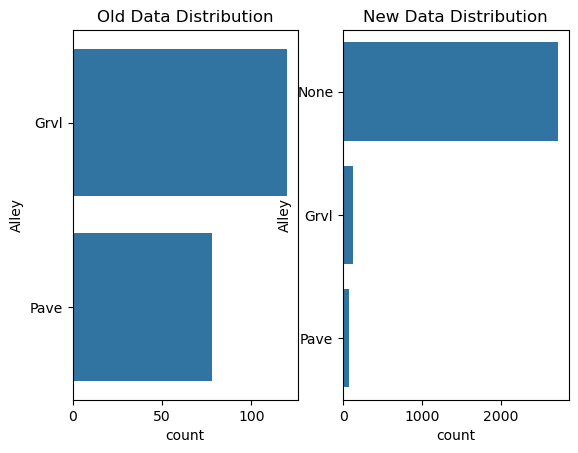

In [42]:
old_new_countPlot(df , df_mvi,"Alley")

## Handling LotFrontage = 16.649538

In [43]:
def boxHistPlot(df, figsize=(16,5)):
    plt.figure(figsize=figsize)
    plt.subplot(121)
    sns.boxplot(df)
    plt.subplot(122)
    sns.histplot(df, kde=True)  # kde=True adds the curve line
    plt.show()

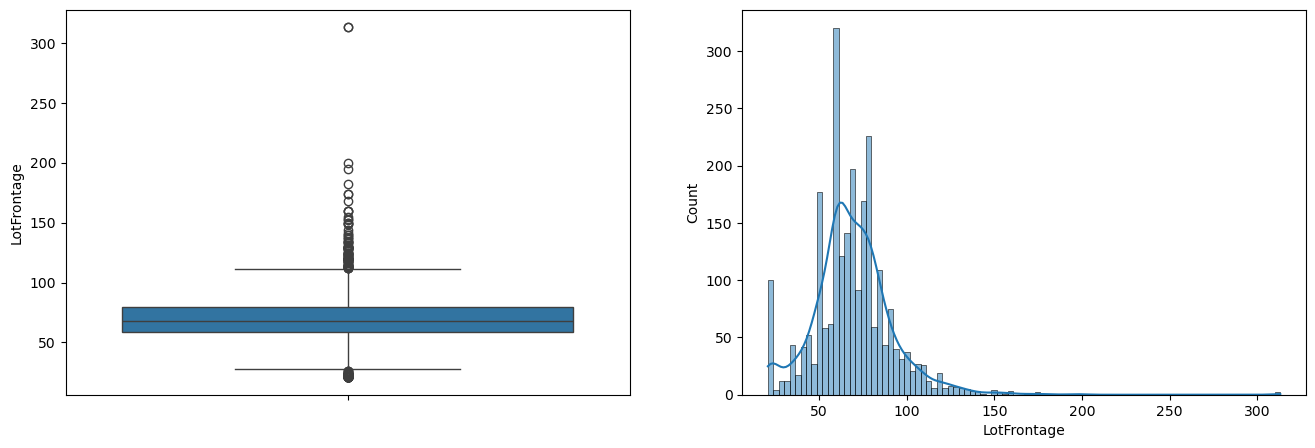

In [44]:
boxHistPlot(df["LotFrontage"])

In [45]:
lotfrontage_mean = df_mvi["LotFrontage"].mean()
df_mvi["LotFrontage"] = df_mvi["LotFrontage"].fillna(lotfrontage_mean)


print(df_mvi["LotFrontage"].isnull().sum())

0


In [46]:
def oldNewBoxHistPlot(df, df_new, feature, figsize = (16,10)):
    plt.figure(figsize = figsize)
    
    plt.subplot(221)
    sns.boxplot(df[feature])
    plt.title("Old Data Distribution")
    plt.subplot(222)
    sns.histplot(df, kde=True)
    plt.title("Old Data Distribution")
    
    plt.subplot(223)
    sns.boxplot(df_new[feature])
    plt.title("New Data Distribution")
    plt.subplot(224)
    sns.histplot(df_new[feature], kde=True)
    plt.title("New Data Distribution")

C:\Users\rasto\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\rasto\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


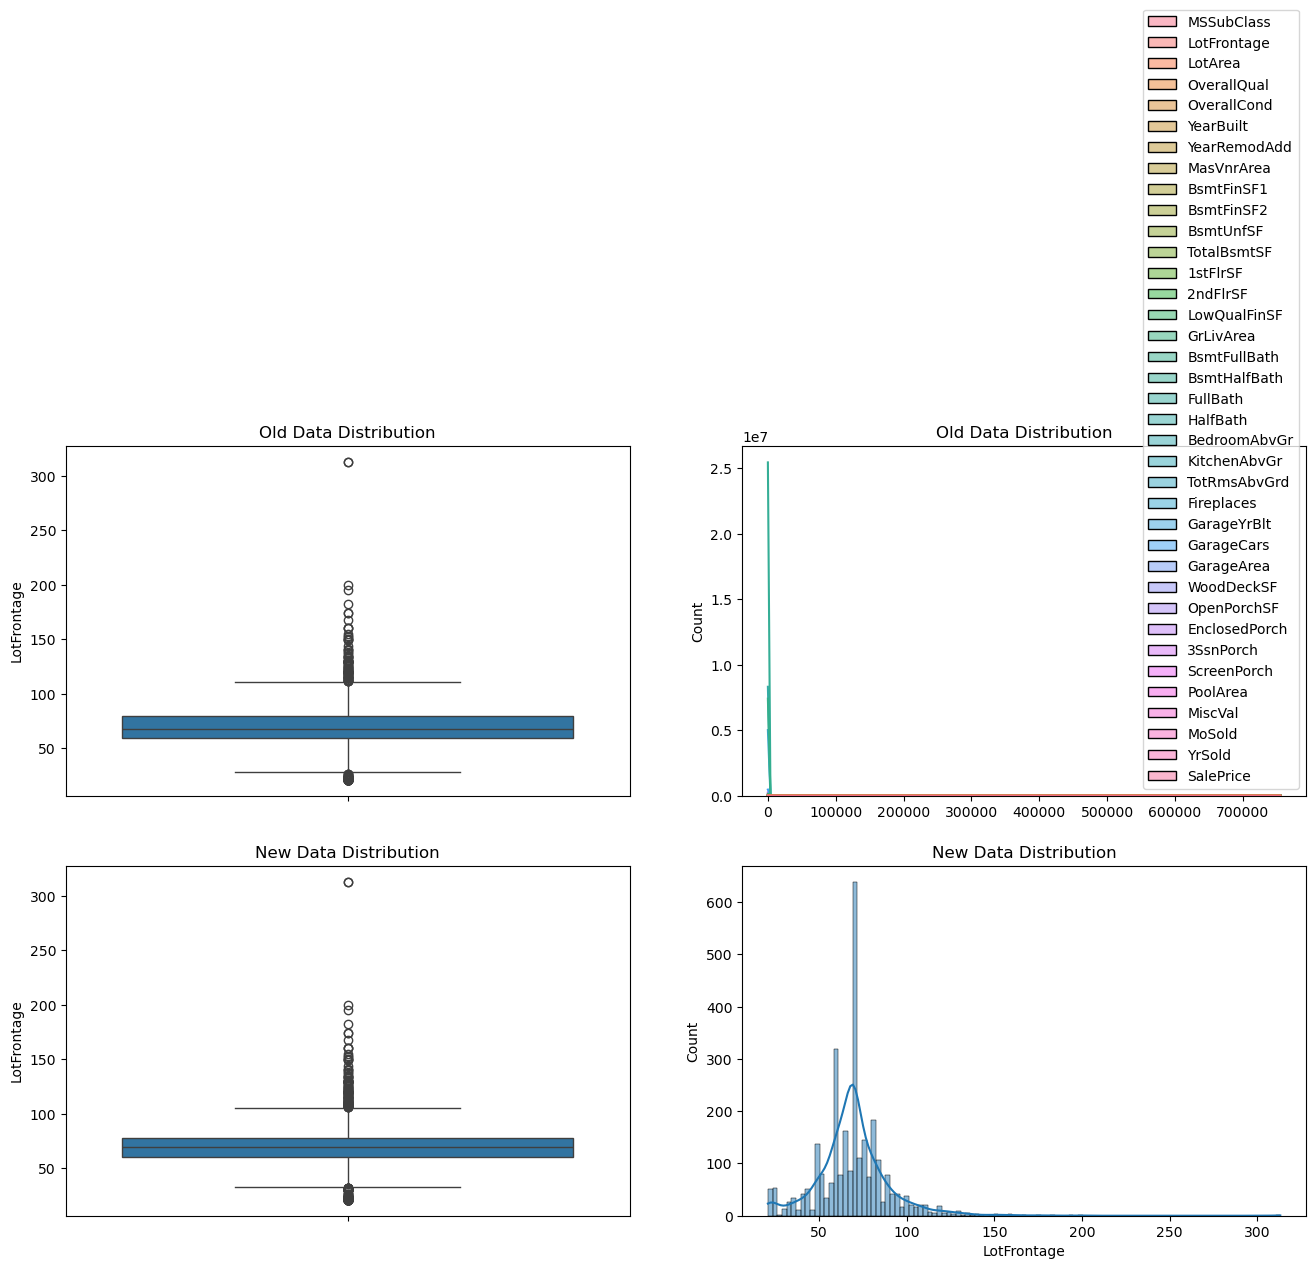

In [47]:
oldNewBoxHistPlot(df, df_mvi, "LotFrontage")

## Handling MasVnrType = 60.500171  MasVnrArea = 0.787941

<Axes: ylabel='Id'>

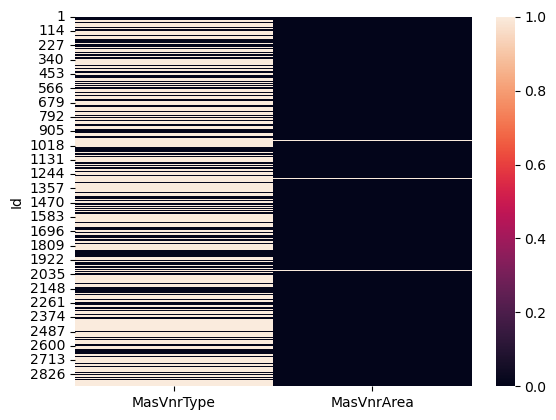

In [48]:
sns.heatmap(df[['MasVnrType', 'MasVnrArea']].isnull())

In [49]:
df["MasVnrType"].value_counts()

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64

In [50]:
# First, verify they're missing together
print(df[['MasVnrType', 'MasVnrArea']].isnull().sum())

# Check rows where both are null
missing_both = df[df['MasVnrType'].isnull() & df['MasVnrArea'].isnull()]
print(f"Both missing: {len(missing_both)}")

MasVnrType    1766
MasVnrArea      23
dtype: int64
Both missing: 23


In [51]:
# Fill MasVnrType with 'None' (meaning no masonry veneer)
df['MasVnrType'] = df['MasVnrType'].fillna('None')

# Fill MasVnrArea with 0 (no veneer = 0 area)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [52]:
print(df[['MasVnrType', 'MasVnrArea']].isnull().sum())
# Should show 0 nulls for both

MasVnrType    0
MasVnrArea    0
dtype: int64


## Handling Bsmt Features

In [53]:
"""BsmtCond         2.809181
BsmtExposure     2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406"""

'BsmtCond         2.809181\nBsmtExposure     2.809181\nBsmtQual         2.774923\nBsmtFinType2     2.740665\nBsmtFinType1     2.706406'

In [54]:
cat_bsmt_features = ['BsmtCond', 'BsmtExposure', 'BsmtQual', 'BsmtFinType2', 'BsmtFinType1']


<Axes: ylabel='Id'>

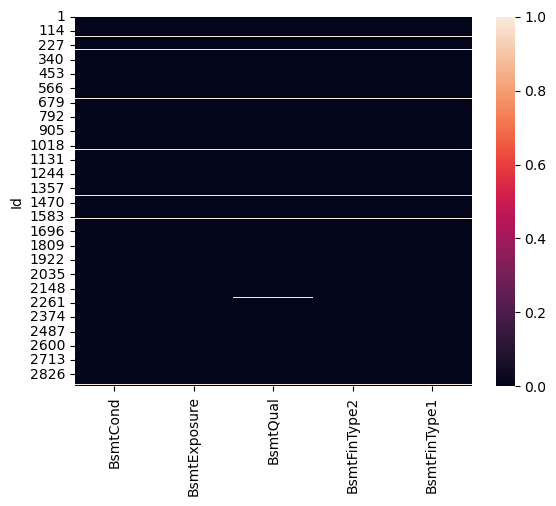

In [55]:
sns.heatmap(df[cat_bsmt_features].isnull())

In [56]:
for feature in cat_bsmt_features:
    print(f"{feature} value counts:\n{df[feature].value_counts()}\n")

BsmtCond value counts:
BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64

BsmtExposure value counts:
BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64

BsmtQual value counts:
BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64

BsmtFinType2 value counts:
BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64

BsmtFinType1 value counts:
BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64



In [57]:
bsmt_cont = "None"

for feature in cat_bsmt_features:
    df_mvi[feature] = df_mvi[feature].fillna(bsmt_cont)
    df[feature] = df[feature].fillna(bsmt_cont)


In [58]:
print(df_mvi[cat_bsmt_features].isnull().sum())
print(df[cat_bsmt_features].isnull().sum())

BsmtCond        0
BsmtExposure    0
BsmtQual        0
BsmtFinType2    0
BsmtFinType1    0
dtype: int64
BsmtCond        0
BsmtExposure    0
BsmtQual        0
BsmtFinType2    0
BsmtFinType1    0
dtype: int64


## Handling Other Features

In [59]:
cat_features = ["FireplaceQu", "PoolQC", "Fence", "MiscFeature"]

<Axes: ylabel='Id'>

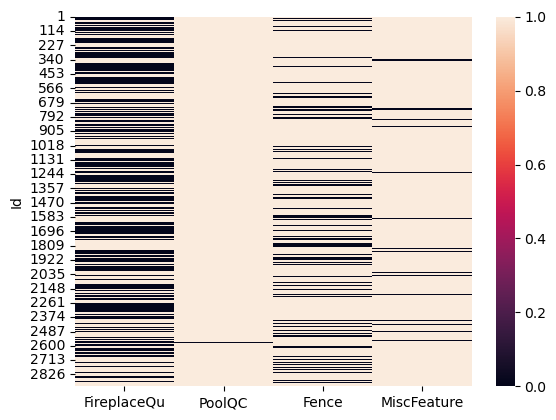

In [60]:
sns.heatmap(df[cat_features].isnull())

In [61]:
for feature in cat_features:
    print(f"{feature} value counts:\n{df[feature].value_counts()}\n")

FireplaceQu value counts:
FireplaceQu
Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: count, dtype: int64

PoolQC value counts:
PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64

Fence value counts:
Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64

MiscFeature value counts:
MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64



In [62]:
fireplacequ_count = "NA"
df_mvi["FireplaceQu"].replace(np.nan, fireplacequ_count , inplace = True)
df_mvi["FireplaceQu"].isnull().sum()


C:\Users\rasto\AppData\Local\Temp\ipykernel_38200\935587017.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["FireplaceQu"].replace(np.nan, fireplacequ_count , inplace = True)


np.int64(0)

In [63]:
poolqc_count = "NA"
df_mvi["PoolQC"].replace(np.nan, poolqc_count , inplace = True)
df_mvi["PoolQC"].isnull().sum()

C:\Users\rasto\AppData\Local\Temp\ipykernel_38200\3995166731.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["PoolQC"].replace(np.nan, poolqc_count , inplace = True)


np.int64(0)

In [64]:
fence_cont = "NA"
df_mvi["Fence"].replace(np.nan, fence_cont , inplace = True)
df_mvi["Fence"].isnull().sum()

C:\Users\rasto\AppData\Local\Temp\ipykernel_38200\1217873095.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["Fence"].replace(np.nan, fence_cont , inplace = True)


np.int64(0)

In [65]:
miscfeature_cont = "NA"
df_mvi["MiscFeature"].replace(np.nan, miscfeature_cont , inplace = True)
df_mvi["MiscFeature"].isnull().sum()

C:\Users\rasto\AppData\Local\Temp\ipykernel_38200\4009795612.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["MiscFeature"].replace(np.nan, miscfeature_cont , inplace = True)


np.int64(0)

## Handling Garage Feature

In [66]:
"""Car_feature
GarageCond       5.447071
GarageQual       5.447071
GarageFinish     5.447071
GarageType       5.378554

Num_feature
GarageYrBlt     5.447071"""

'Car_feature\nGarageCond       5.447071\nGarageQual       5.447071\nGarageFinish     5.447071\nGarageType       5.378554\n\nNum_feature\nGarageYrBlt     5.447071'

In [67]:
gar_features = ["GarageCond", "GarageQual", "GarageFinish", "GarageType"]

<Axes: ylabel='Id'>

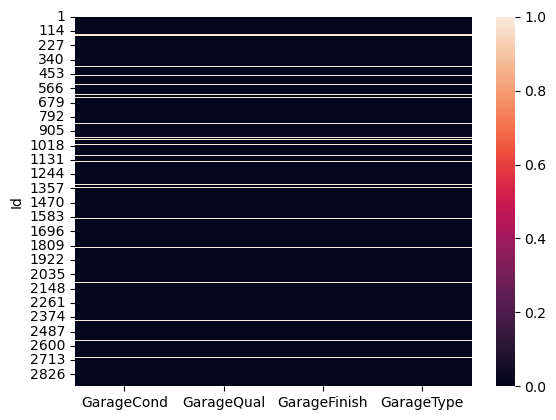

In [68]:
sns.heatmap(df[gar_features].isnull())

In [69]:
for feature in gar_features:
    print(f"{feature} value counts:\n{df[feature].value_counts()}\n")

GarageCond value counts:
GarageCond
TA    2654
Fa      74
Gd      15
Po      14
Ex       3
Name: count, dtype: int64

GarageQual value counts:
GarageQual
TA    2604
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64

GarageFinish value counts:
GarageFinish
Unf    1230
RFn     811
Fin     719
Name: count, dtype: int64

GarageType value counts:
GarageType
Attchd     1723
Detchd      779
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64



In [70]:
garage_count = "None"

for feature in gar_features:
    df_mvi[feature] = df_mvi[feature].fillna(garage_count)


print(df_mvi[gar_features].isnull().sum())

GarageCond      0
GarageQual      0
GarageFinish    0
GarageType      0
dtype: int64


In [71]:
# Fill with number 0, not string "0"
df_mvi["GarageYrBlt"] = df_mvi["GarageYrBlt"].fillna(0)

# Convert back to float
df_mvi["GarageYrBlt"] = df_mvi["GarageYrBlt"].astype(float)

# Verify
print(df_mvi["GarageYrBlt"].dtype)  # should show float64

float64


In [72]:
df_mvi["MasVnrType"] = df_mvi["MasVnrType"].fillna("None")
df_mvi["MasVnrArea"] = df_mvi["MasVnrArea"].fillna(0)

In [73]:
df_mvi["FireplaceQu"] = df_mvi["FireplaceQu"].fillna("None")

In [74]:
df_mvi["PoolQC"] = df_mvi["PoolQC"].fillna("None")
df_mvi["Fence"] = df_mvi["Fence"].fillna("None")
df_mvi["MiscFeature"] = df_mvi["MiscFeature"].fillna("None")

In [75]:
small_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
              'Electrical', 'KitchenQual', 'Functional', 'SaleType']

for col in small_cols:
    df_mvi[col] = df_mvi[col].fillna(df_mvi[col].mode()[0])

In [76]:
num_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
            'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

for col in num_cols:
    df_mvi[col] = df_mvi[col].fillna(df_mvi[col].median())

In [77]:
df_mvi.isnull().sum()[df_mvi.isnull().sum() > 0]
# Should only show SalePrice 1459 — nothing else

SalePrice    1459
dtype: int64

##  Feature Transformation

### Convert Numerical Feature to Categorical feature 

### feature engineering

In [78]:
for_num_conv = ["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]

for feat in for_num_conv:
    print(f"{feat}: data type = {df_mvi[feat].dtype}")

MSSubClass: data type = int64
YearBuilt: data type = int64
YearRemodAdd: data type = int64
GarageYrBlt: data type = float64
MoSold: data type = int64
YrSold: data type = int64


In [79]:
df_mvi[for_num_conv].head()

,MSSubClass,YearBuilt,YearRemodAdd,GarageYrBlt,MoSold,YrSold
Id,,,,,,
1,60,2003,2003,2003.0,2,2008
2,20,1976,1976,1976.0,5,2007
3,60,2001,2002,2001.0,9,2008
4,70,1915,1970,1998.0,2,2006
5,60,2000,2000,2000.0,12,2008


In [80]:
df_mvi["MoSold"].unique()

array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6])

In [81]:
df_mvi["MoSold"] = df_mvi["MoSold"].apply(lambda x : calendar.month_abbr[x])
df_mvi["MoSold"].unique()

array(['Feb', 'May', 'Sep', 'Dec', 'Oct', 'Aug', 'Nov', 'Apr', 'Jan',
       'Jul', 'Mar', 'Jun'], dtype=object)

In [82]:
for feature in for_num_conv:
    df_mvi[feature] = df_mvi[feature].astype(str)

In [83]:
for feature in for_num_conv:
    print(f"{feature}: data type = {df_mvi[feature].dtype}")

MSSubClass: data type = object
YearBuilt: data type = object
YearRemodAdd: data type = object
GarageYrBlt: data type = object
MoSold: data type = object
YrSold: data type = object


## Convert categorical features into numerical feature 

### ordinal Encoding

In [84]:
ordinal_end_var = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
                   "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                   "HeatingQC", "KitchenQual", "FireplaceQu", 
                   "GarageQual", "GarageCond", "PoolQC", 
                   "Utilities", "Functional", "PavedDrive", "GarageFinish"]

print("Total number of ordinal features: ", len(ordinal_end_var))

Total number of ordinal features:  17


In [85]:
# Step 2 - Restore all columns from original df_train first
for col in ordinal_end_var:
    df_mvi[col] = df_train[col].copy()

# Verify all columns have data
for col in ordinal_end_var:
    print(f"{col}: {df_mvi[col].unique()}")

ExterQual: ['TA' 'Gd' 'Ex' 'Fa' nan]
ExterCond: ['TA' 'Gd' 'Fa' 'Po' 'Ex' nan]
BsmtQual: ['Gd' 'TA' 'Ex' nan 'Fa']
BsmtCond: ['TA' 'Gd' nan 'Fa' 'Po']
BsmtExposure: ['Gd' 'Mn' 'No' 'Av' nan]
BsmtFinType1: ['ALQ' 'GLQ' 'Unf' 'Rec' 'BLQ' nan 'LwQ']
BsmtFinType2: ['Unf' 'BLQ' nan 'ALQ' 'Rec' 'LwQ' 'GLQ']
HeatingQC: ['Ex' 'Gd' 'TA' 'Fa' 'Po' nan]
KitchenQual: ['TA' 'Gd' 'Ex' 'Fa' nan]
FireplaceQu: ['TA' 'Gd' nan 'Fa' 'Ex' 'Po']
GarageQual: ['TA' 'Fa' 'Gd' nan 'Ex' 'Po']
GarageCond: ['TA' 'Fa' nan 'Gd' 'Po' 'Ex']
PoolQC: [nan 'Ex' 'Fa' 'Gd']
Utilities: ['AllPub' 'NoSeWa' nan]
Functional: ['Typ' 'Min1' 'Maj1' 'Min2' 'Mod' 'Maj2' 'Sev' nan]
PavedDrive: ['Y' 'N' 'P' nan]
GarageFinish: ['RFn' 'Unf' 'Fin' nan]


In [86]:
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
for col in ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
            "HeatingQC", "KitchenQual", "FireplaceQu",
            "GarageQual", "GarageCond", "PoolQC"]:
    df_mvi[col] = df_mvi[col].map(qual_map)

In [87]:
bsmt_exp_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
df_mvi["BsmtExposure"] = df_mvi["BsmtExposure"].map(bsmt_exp_map)

In [88]:
bsmt_fin_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
df_mvi["BsmtFinType1"] = df_mvi["BsmtFinType1"].map(bsmt_fin_map)
df_mvi["BsmtFinType2"] = df_mvi["BsmtFinType2"].map(bsmt_fin_map)

In [89]:
utilities_map = {"None": 0, "ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4}
df_mvi["Utilities"] = df_mvi["Utilities"].map(utilities_map)

In [90]:
utilities_map = {"None": 0, "ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4}
df_mvi["Utilities"] = df_mvi["Utilities"].map(utilities_map)

In [91]:
paved_map = {"N": 0, "P": 1, "Y": 2}
df_mvi["PavedDrive"] = df_mvi["PavedDrive"].map(paved_map)

In [92]:
garage_fin_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
df_mvi["GarageFinish"] = df_mvi["GarageFinish"].map(garage_fin_map)

In [93]:
# Direct fix
df_mvi['GarageFinish'] = df_mvi['GarageFinish'].fillna(0).astype(int)

# Verify
print(df_mvi['GarageFinish'].value_counts())
print(f"Dtype: {df_mvi['GarageFinish'].dtype}")
print(f"Nulls: {df_mvi['GarageFinish'].isnull().sum()}")

GarageFinish
0    1541
1     605
2     421
3     352
Name: count, dtype: int64
Dtype: int64
Nulls: 0


In [94]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      0 non-null      float64
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt    

In [95]:
df_mvi.drop(columns=['Utilities'], inplace=True)
print("✅ Utilities dropped")

✅ Utilities dropped


In [96]:
# 2. These were label encoded but still float — fix to int
float_to_int_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC'
]

In [97]:
for col in float_to_int_cols:
    if col in df_mvi.columns:
        df_mvi[col] = df_mvi[col].fillna(0).astype(int)
        print(f"✅ {col} → int")


✅ ExterQual → int
✅ ExterCond → int
✅ BsmtQual → int
✅ BsmtCond → int
✅ BsmtExposure → int
✅ BsmtFinType1 → int
✅ BsmtFinType2 → int
✅ HeatingQC → int
✅ KitchenQual → int
✅ FireplaceQu → int
✅ GarageQual → int
✅ GarageCond → int
✅ PavedDrive → int
✅ PoolQC → int


In [98]:
df_mvi['Functional'] = df_mvi['Functional'].fillna(df_mvi['Functional'].mode()[0])
print("✅ Functional filled")

✅ Functional filled


In [99]:
print("\n===== REMAINING NULLS =====")
nulls = df_mvi.isnull().sum()
print(nulls[nulls > 0])


===== REMAINING NULLS =====
SalePrice    1459
dtype: int64


In [100]:
print("\n===== DTYPES SUMMARY =====")
print(df_mvi.dtypes.value_counts())


===== DTYPES SUMMARY =====
int64      35
object     33
float64    11
Name: count, dtype: int64


In [101]:
# Check which columns are still float
float_cols = df_mvi.select_dtypes(include='float64').columns.tolist()
print("Float64 columns remaining:")
for col in float_cols:
    print(f"{col}: nulls={df_mvi[col].isnull().sum()}, unique={df_mvi[col].nunique()}, sample={df_mvi[col].dropna().unique()[:5]}")

Float64 columns remaining:
LotFrontage: nulls=0, unique=129, sample=[65. 80. 68. 60. 84.]
MasVnrArea: nulls=0, unique=444, sample=[196.   0. 162. 350. 186.]
BsmtFinSF1: nulls=0, unique=992, sample=[706. 978. 486. 216. 655.]
BsmtFinSF2: nulls=0, unique=272, sample=[  0.  32. 668. 486.  93.]
BsmtUnfSF: nulls=0, unique=1135, sample=[150. 284. 434. 540. 490.]
TotalBsmtSF: nulls=0, unique=1059, sample=[ 856. 1262.  920.  756. 1145.]
BsmtFullBath: nulls=0, unique=4, sample=[1. 0. 2. 3.]
BsmtHalfBath: nulls=0, unique=3, sample=[0. 1. 2.]
GarageCars: nulls=0, unique=6, sample=[2. 3. 1. 0. 4.]
GarageArea: nulls=0, unique=603, sample=[548. 460. 608. 642. 836.]
SalePrice: nulls=1459, unique=663, sample=[208500. 181500. 223500. 140000. 250000.]


In [102]:
whole_num_cols = ['BsmtFullBath', 'BsmtHalfBath', 'GarageCars']

for col in whole_num_cols:
    df_mvi[col] = df_mvi[col].astype(int)
    print(f"✅ {col} → int")


✅ BsmtFullBath → int
✅ BsmtHalfBath → int
✅ GarageCars → int


In [103]:
print("\n===== FINAL DTYPES =====")
print(df_mvi.dtypes.value_counts())



===== FINAL DTYPES =====
int64      38
object     33
float64     8
Name: count, dtype: int64


In [104]:
print("\n===== NULL CHECK =====")
nulls = df_mvi.isnull().sum()
remaining = nulls[nulls > 0]
print(remaining if len(remaining) > 0 else "✅ Zero nulls (except SalePrice)!")


===== NULL CHECK =====
SalePrice    1459
dtype: int64


In [105]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   LotConfig      2919 non-null   object 
 9   LandSlope      2919 non-null   object 
 10  Neighborhood   2919 non-null   object 
 11  Condition1     2919 non-null   object 
 12  Condition2     2919 non-null   object 
 13  BldgType       2919 non-null   object 
 14  HouseStyle     2919 non-null   object 
 15  OverallQual    2919 non-null   int64  
 16  OverallCond    2919 non-null   int64  
 17  YearBuilt      2919 non-null   object 
 18  YearRemodAdd 

In [106]:
# First let's see all object columns and their unique values
obj_cols = df_mvi.select_dtypes(include='object').columns.tolist()

for col in obj_cols:
    print(f"{col}: {df_mvi[col].nunique()} unique → {df_mvi[col].unique()[:5]}")

MSSubClass: 16 unique → ['60' '20' '70' '50' '190']
MSZoning: 5 unique → ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street: 2 unique → ['Pave' 'Grvl']
Alley: 3 unique → ['None' 'Grvl' 'Pave']
LotShape: 4 unique → ['Reg' 'IR1' 'IR2' 'IR3']
LandContour: 4 unique → ['Lvl' 'Bnk' 'Low' 'HLS']
LotConfig: 5 unique → ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope: 3 unique → ['Gtl' 'Mod' 'Sev']
Neighborhood: 25 unique → ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel']
Condition1: 9 unique → ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe']
Condition2: 8 unique → ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN']
BldgType: 5 unique → ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle: 8 unique → ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer']
YearBuilt: 118 unique → ['2003' '1976' '2001' '1915' '2000']
YearRemodAdd: 61 unique → ['2003' '1976' '2002' '1970' '2000']
RoofStyle: 6 unique → ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat']
RoofMatl: 8 unique → ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran']
Exterior1st: 15 u

In [107]:
ordinal_cols = {
    'LotShape'  : ['IR3', 'IR2', 'IR1', 'Reg'],        # most irregular → regular
    'LandSlope' : ['Sev', 'Mod', 'Gtl'],                # severe → gentle
    'Street'    : ['Grvl', 'Pave'],                     # gravel → paved
    'Alley'     : ['None', 'Grvl', 'Pave'],             # no alley → paved
    'CentralAir': ['N', 'Y'],                           # No → Yes
    'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1',
                   'Mod', 'Min2', 'Min1', 'Typ'],       # salvage → typical
    'Fence'     : ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],  # no fence → good privacy
}

In [108]:
for col, order in ordinal_cols.items():
    mapping = {val: i for i, val in enumerate(order)}
    df_mvi[col] = df_mvi[col].map(mapping)
    print(f"✅ {col} → {mapping}")

✅ LotShape → {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3}
✅ LandSlope → {'Sev': 0, 'Mod': 1, 'Gtl': 2}
✅ Street → {'Grvl': 0, 'Pave': 1}
✅ Alley → {'None': 0, 'Grvl': 1, 'Pave': 2}
✅ CentralAir → {'N': 0, 'Y': 1}
✅ Functional → {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
✅ Fence → {'NA': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}


In [109]:
# ============ STEP 2: YEAR COLUMNS (extract as int) ============
# YearBuilt, YearRemodAdd, GarageYrBlt are years stored as string
# Don't OHE them — too many unique values, treat as numeric

year_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

for col in year_cols:
    df_mvi[col] = df_mvi[col].astype(float).astype(int)
    print(f"✅ {col} → int")

✅ YearBuilt → int
✅ YearRemodAdd → int
✅ GarageYrBlt → int


In [110]:
# MoSold has month names — map them to numbers first
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_mvi['MoSold'] = df_mvi['MoSold'].map(month_map)
print(f"✅ MoSold → {df_mvi['MoSold'].unique()}")

# Now convert remaining year cols normally
year_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']

for col in year_cols:
    df_mvi[col] = df_mvi[col].astype(float).astype(int)
    print(f"✅ {col} → int")

# Verify
print("\n===== CHECK =====")
check_cols = ['MoSold', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']
print(df_mvi[check_cols].dtypes)
print(df_mvi[check_cols].head())

✅ MoSold → [ 2  5  9 12 10  8 11  4  1  7  3  6]
✅ YearBuilt → int
✅ YearRemodAdd → int
✅ GarageYrBlt → int
✅ YrSold → int

===== CHECK =====
MoSold          int64
YearBuilt       int64
YearRemodAdd    int64
GarageYrBlt     int64
YrSold          int64
dtype: object
    MoSold  YearBuilt  YearRemodAdd  GarageYrBlt  YrSold
Id                                                      
1        2       2003          2003         2003    2008
2        5       1976          1976         1976    2007
3        9       2001          2002         2001    2008
4        2       1915          1970         1998    2006
5       12       2000          2000         2000    2008


In [111]:
# ============ STEP 3: ONE-HOT ENCODING (no order) ============
nominal_cols = [
    'MSSubClass',   # house type code — no order
    'MSZoning',     # zoning type
    'LandContour',  # flatness
    'LotConfig',    # lot configuration
    'Neighborhood', # location — 25 categories
    'Condition1',   # proximity to road/railroad
    'Condition2',
    'BldgType',     # building type
    'HouseStyle',   # house style
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'Electrical',
    'GarageType',
    'MiscFeature',
    'SaleType',
    'SaleCondition',
]

df_mvi = pd.get_dummies(df_mvi, columns=nominal_cols, drop_first=True)
print(f"✅ OHE done — Shape now: {df_mvi.shape}")

✅ OHE done — Shape now: (2919, 215)


In [112]:
# ============ STEP 4: VERIFY ============
print("===== DTYPES =====")
print(df_mvi.dtypes.value_counts())

print("\n===== OBJECT COLS REMAINING =====")
remaining = df_mvi.select_dtypes(include='object').columns.tolist()
print(remaining if remaining else "✅ No object columns left!")

print("\n===== SHAPE =====")
print(df_mvi.shape)

===== DTYPES =====
bool       157
int64       50
float64      8
Name: count, dtype: int64

===== OBJECT COLS REMAINING =====
✅ No object columns left!

===== SHAPE =====
(2919, 215)


In [113]:
# Convert bool columns to int (True→1, False→0)
bool_cols = df_mvi.select_dtypes(include='bool').columns.tolist()
df_mvi[bool_cols] = df_mvi[bool_cols].astype(int)
print(f"✅ {len(bool_cols)} bool columns converted to int")

# Final verification
print("\n===== FINAL DTYPES =====")
print(df_mvi.dtypes.value_counts())

print("\n===== SHAPE =====")
print(df_mvi.shape)  # (2919, 215)

print("\n===== NULL CHECK =====")
nulls = df_mvi.isnull().sum()
remaining = nulls[nulls > 0]
print(remaining if len(remaining) > 0 else "✅ Zero nulls (except SalePrice)!")

✅ 157 bool columns converted to int

===== FINAL DTYPES =====
int64      207
float64      8
Name: count, dtype: int64

===== SHAPE =====
(2919, 215)

===== NULL CHECK =====
SalePrice    1459
dtype: int64


In [114]:
df_mvi.select_dtypes(include="object").columns.tolist()

[]

In [115]:
df_mvi.head()

,LotFrontage,LotArea,Street,Alley,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,SalePrice,MSSubClass_150,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_NA,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,1,0,3,2,7,5,2003,2003,196.0,3,3,4,3,4,5,706.0,1,0.0,150.0,856.0,5,1,856,854,0,1710,1,0,2,1,3,1,3,8,7,0,3,2003,2,2,548.0,3,3,2,0,61,0,0,0,0,0,0,0,2,2008,208500.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0

## split Data For Training and Testing 

In [116]:
# CHECK — what is in float_cols right now?
print(float_cols)

['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea', 'SalePrice']


In [117]:
df_train_processed = df_mvi[df_mvi['SalePrice'].notna()].copy()
df_test_processed  = df_mvi[df_mvi['SalePrice'].isna()].copy()

X = df_train_processed.drop(columns=['SalePrice'])
y = df_train_processed['SalePrice']

In [118]:
# ============ CORRECT WAY — get float cols AFTER removing SalePrice ============


# Step 2 - Split
X_train, X_val, y_train, y_val = train_test_split(
                                    X, y,
                                    test_size=0.2,
                                    random_state=42
                                )

feature_columns = X_train.columns.tolist()

In [119]:
# Step 3 - Get float cols FROM X_train (no SalePrice here)
float_cols = X_train.select_dtypes(include='float64').columns.tolist()
print(f"Float cols: {float_cols}")   # SalePrice should NOT appear here

Float cols: ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageArea']


In [120]:
# Step 4 - Scale
scaler = StandardScaler()
X_train[float_cols] = scaler.fit_transform(X_train[float_cols])
X_val[float_cols]   = scaler.transform(X_val[float_cols])

X_test = df_test_processed.drop(columns=['SalePrice'])
X_test[float_cols]  = scaler.transform(X_test[float_cols])

print("✅ Scaling done!")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

✅ Scaling done!
X_train : (1168, 214)
X_val   : (292, 214)
X_test  : (1459, 214)


## Model Regression 

In [121]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_val)

# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr   = r2_score(y_val, y_pred_lr)

print("===== LINEAR REGRESSION =====")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"R²   : {r2_lr:.4f}")

===== LINEAR REGRESSION =====
RMSE : 50,190.98
R²   : 0.6716


## Random Forest

In [122]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf   = r2_score(y_val, y_pred_rf)

print("===== RANDOM FOREST =====")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

===== RANDOM FOREST =====
RMSE : 29,380.97
R²   : 0.8875


## XGBOOST

In [123]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
rmse_xgb   = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb     = r2_score(y_val, y_pred_xgb)

print("===== XGBOOST =====")
print(f"RMSE : {rmse_xgb:,.2f}")
print(f"R²   : {r2_xgb:.4f}")

===== XGBOOST =====
RMSE : 26,126.63
R²   : 0.9110


# ============ COMPARE ALL 3 Models============

In [124]:

print("========== MODEL COMPARISON ==========")
print(f"{'Model':<20} {'RMSE':>12} {'R²':>10}")
print("-" * 45)
print(f"{'Linear Regression':<20} {rmse_lr:>12,.2f} {r2_lr:>10.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>12,.2f} {r2_rf:>10.4f}")
print(f"{'XGBoost':<20} {rmse_xgb:>12,.2f} {r2_xgb:>10.4f}")
print("-" * 45)

========== MODEL COMPARISON ==========
Model                        RMSE         R²
---------------------------------------------
Linear Regression       50,190.98     0.6716
Random Forest           29,380.97     0.8875
XGBoost                 26,126.63     0.9110
---------------------------------------------


# ============ ACTUAL VS PREDICTED PLOT ============

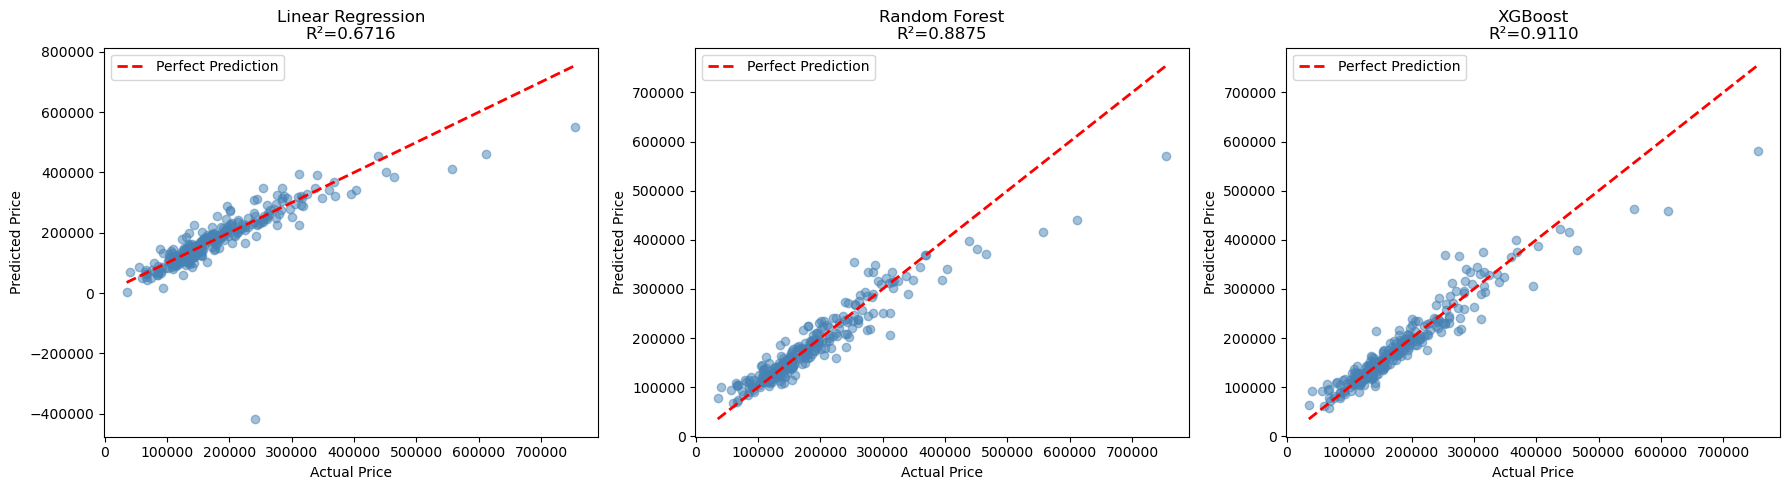

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Linear Regression': y_pred_lr,
    'Random Forest'    : y_pred_rf,
    'XGBoost'          : y_pred_xgb
}

for ax, (name, y_pred) in zip(axes, models.items()):
    ax.scatter(y_val, y_pred, alpha=0.5, color='steelblue')
    ax.plot([y_val.min(), y_val.max()],
            [y_val.min(), y_val.max()],
            'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name}\nR²={r2_score(y_val, y_pred):.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

# ============ FEATURE IMPORTANCE (XGBoost) ============

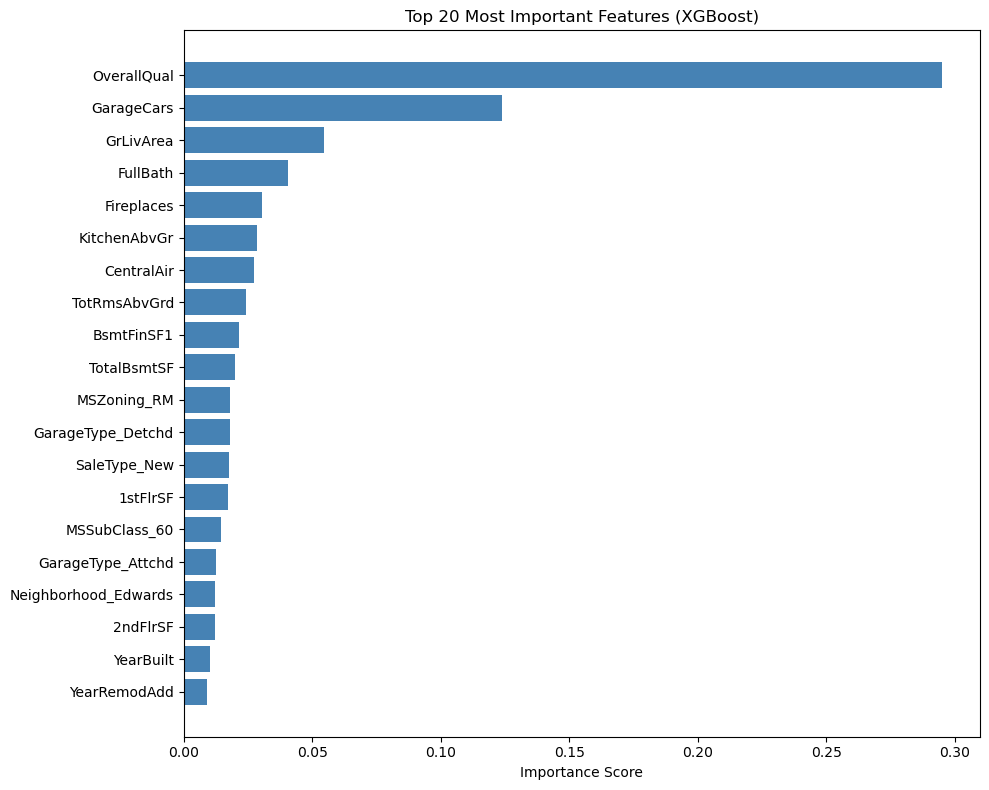


Top 10 Features:
     Feature  Importance
 OverallQual    0.295033
  GarageCars    0.123978
   GrLivArea    0.054464
    FullBath    0.040482
  Fireplaces    0.030626
KitchenAbvGr    0.028351
  CentralAir    0.027253
TotRmsAbvGrd    0.024255
  BsmtFinSF1    0.021625
 TotalBsmtSF    0.019759


In [126]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features (XGBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 10 Features:")
print(feat_imp.head(10).to_string(index=False))

# ============ FINAL PREDICTION ON TEST SET ============
# Use best model (XGBoost) to predict on unseen test data

In [127]:
test_predictions = xgb_model.predict(X_test)

# Save to submission file
submission = pd.DataFrame({
    'Id': df_test.index,
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("✅ submission.csv saved!")
print(submission.head(10))

✅ submission.csv saved!
   Id      SalePrice
0   0  116151.734375
1   1  163735.984375
2   2  177701.015625
3   3  190563.828125
4   4  195537.765625
5   5  173952.609375
6   6  174578.468750
7   7  163382.078125
8   8  177097.062500
9   9  114289.492188


# ============ SAVE THE MODEL ============

In [131]:
joblib.dump(xgb_model,       'house_price_xgb_model.pkl')
joblib.dump(scaler,          'scaler.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')
joblib.dump(float_cols,      'float_cols.pkl')

print("✅ house_price_xgb_model.pkl saved")
print("✅ scaler.pkl saved")
print("✅ feature_columns.pkl saved")
print("✅ float_cols.pkl saved")

✅ house_price_xgb_model.pkl saved
✅ scaler.pkl saved
✅ feature_columns.pkl saved
✅ float_cols.pkl saved


# ============ VERIFY SUBMISSION ============

In [129]:
submission = pd.read_csv('submission.csv')

print("===== SUBMISSION FILE =====")
print(f"Shape    : {submission.shape}")
print(f"Nulls    : {submission.isnull().sum().sum()}")
print(f"\nSample predictions:")
print(submission.head(10))

print(f"\nPrice Statistics:")
print(f"Min  Price: ${submission['SalePrice'].min():,.2f}")
print(f"Max  Price: ${submission['SalePrice'].max():,.2f}")
print(f"Mean Price: ${submission['SalePrice'].mean():,.2f}")

===== SUBMISSION FILE =====
Shape    : (1459, 2)
Nulls    : 0

Sample predictions:
   Id   SalePrice
0   0  116151.734
1   1  163735.980
2   2  177701.020
3   3  190563.830
4   4  195537.770
5   5  173952.610
6   6  174578.470
7   7  163382.080
8   8  177097.060
9   9  114289.490

Price Statistics:
Min  Price: $44,204.60
Max  Price: $498,304.06
Mean Price: $174,898.06


# ============ PLOT PREDICTED PRICE DISTRIBUTION ============

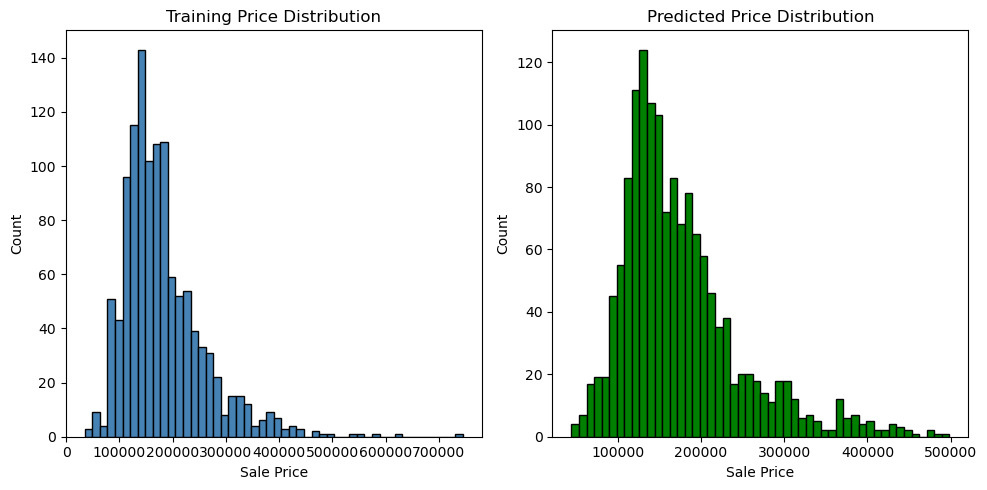

In [130]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, color='steelblue', edgecolor='black')
plt.title('Training Price Distribution')
plt.xlabel('Sale Price')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(submission['SalePrice'], bins=50, color='green', edgecolor='black')
plt.title('Predicted Price Distribution')
plt.xlabel('Sale Price')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()